# 11 · Multiple subjects — compared and interacting

Four model-subjects (each a `BrainScoreModel`): we compare their representations
with inter-subject RSA against a same-brain control and a shuffled null, then
chain their actions through the multi-agent harness and verify the handoff.

(*Subject* is also used for the biological subjects in a dataset — handled by
leave-one-subject-out CV — a different axis; see the end.)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from brainscore_core.model_interface import BrainScoreModel, EnvironmentStep
from brainscore.model_helpers.policy_wrapper import PolicyWrapper
from brainscore.activation_window import ActivationWindow
from brainscore.harnesses.multi_agent import multi_agent_rollout, DialogueMediator

def make_net(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, 8)).eval()
def make_policy(net):
    def policy(observation, history):
        vec = observation.get('incoming') if isinstance(observation, dict) else observation
        if vec is None: vec = np.zeros(8, 'float32')
        v = torch.as_tensor(np.asarray(vec, 'float32')).reshape(-1)[:8]
        with torch.no_grad():
            return net(v.unsqueeze(0)).squeeze(0).numpy()
    return policy

seeds = [0, 1, 2, 0]                      # agent3 shares agent0's seed (identical brain)
nets = [make_net(s) for s in seeds]
agents = [BrainScoreModel(f'agent{i}', None, {}, {}, None,
                          action_fn=PolicyWrapper(make_policy(nets[i]), max_history=4))
          for i in range(4)]
print('4 agents; seeds', seeds, '(agent3 == agent0)')

4 agents; seeds [0, 1, 2, 0] (agent3 == agent0)


## Capture each subject's representations on shared probes

In [2]:
rng = np.random.RandomState(7)
probes = [rng.randn(8).astype('float32') for _ in range(12)]
def agent_reps(agent, net):
    with ActivationWindow(net, layers=['1']) as w:      # 16-d hidden layer
        for p in probes:
            agent.process(EnvironmentStep(observation={'incoming': p}))
    return np.stack([c.reshape(-1) for c in w.by_layer()['1']])
reps = [agent_reps(agents[i], nets[i]) for i in range(4)]
print('per-subject representations:', [r.shape for r in reps], ' # 12 probes x 16 units')

per-subject representations: [(12, 16), (12, 16), (12, 16), (12, 16)]  # 12 probes x 16 units


## Inter-subject RSA, with a control and a null

RSA = Pearson correlation between two subjects' RDMs (range -1..1). Same-seed agents should score ~1.0 (control); a shuffled RDM should score ~0 (null). Anything in between reflects real representational similarity.

agent0 vs agent3 (same brain): 1.000   (control ~1.0)
agent0 vs agent1 (diff brain): 0.577
shuffled null:                 0.016   (~0)


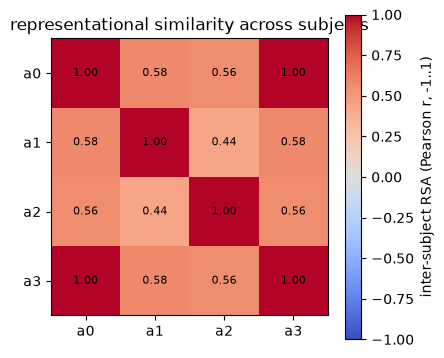

In [3]:
rdms = [1 - np.corrcoef(R) for R in reps]
iu = np.triu_indices_from(rdms[0], k=1)
def rsa(a, b): return float(np.corrcoef(a[iu], b[iu])[0, 1])

M = np.array([[rsa(rdms[i], rdms[j]) for j in range(4)] for i in range(4)])
# shuffled null: agent0's RDM vs a permuted copy of itself
null = np.mean([rsa(rdms[0], (lambda p: (1 - np.corrcoef(reps[0][p]))) (np.random.RandomState(s).permutation(12)))
                for s in range(50)])
print(f'agent0 vs agent3 (same brain): {M[0,3]:.3f}   (control ~1.0)')
print(f'agent0 vs agent1 (diff brain): {M[0,1]:.3f}')
print(f'shuffled null:                 {null:.3f}   (~0)')

fig, ax = plt.subplots(figsize=(4.4, 3.8))
im = ax.imshow(M, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([f'a{i}' for i in range(4)]); ax.set_yticklabels([f'a{i}' for i in range(4)])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='inter-subject RSA (Pearson r, -1..1)')
ax.set_title('representational similarity across subjects'); fig.tight_layout(); plt.show()

## Interaction: verify the handoff

`multi_agent_rollout` routes each agent's action to the next agent's input. We confirm it: re-running agent 1's policy on agent 0's recorded action reproduces agent 1's recorded action, so agent 1 really received it.

In [4]:
transcript = multi_agent_rollout(agents, DialogueMediator(task='pass the signal'), n_turns=3)
print('turns:', [(t['turn'], t['agent']) for t in transcript[:5]], '...')
a0_action = transcript[0]['action']                     # agent0 acted
a1_recorded = transcript[1]['action']                   # agent1 acted next
a1_refed = make_policy(nets[1])({'incoming': a0_action}, None)   # feed a0's action to agent1
print('agent1(agent0.action) reproduces agent1 recorded action:',
      bool(np.allclose(a1_refed, a1_recorded, atol=1e-5)))

turns: [(0, 'agent0'), (0, 'agent1'), (0, 'agent2'), (0, 'agent3'), (1, 'agent0')] ...
agent1(agent0.action) reproduces agent1 recorded action: True


**Reading it:** the RSA matrix shows same-brain agents at ~1.0, different-brain pairs
in between, and the shuffled null near 0 — so the off-diagonal values are real
similarity, not noise. The handoff check confirms one agent's action becomes the
next agent's input.

The *other* meaning of "subjects" — the biological subjects in a dataset — is handled
by the neural benchmarks via leave-one-subject-out CV (10 in Lahner2024, 4 in
Algonauts); that is a property of the data, not of these model-subjects.